In [101]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


In [5]:
Data=pd.read_csv('books.csv')
Data.head()

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


In [12]:
Data.columns

Index(['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories',
       'thumbnail', 'description', 'published_year', 'average_rating',
       'num_pages', 'ratings_count'],
      dtype='object')

In [14]:
print(list(Data.shape))

[6810, 12]


In [16]:
Data_Type = pd.DataFrame(Data.dtypes, columns=['Data Type']).T
Data_Type.columns = Data.columns

Data_Type.style.set_caption("Data Types") \
               .set_properties(**{'text-align': 'center'}) \
               .set_table_styles([{
                   'selector': 'th',
                   'props': [('text-align', 'center')]
               }])

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
Data Type,int64,object,object,object,object,object,object,object,float64,float64,float64,float64


In [18]:
Missing_data=Data.isnull().sum()
Missing_data = Missing_data[Missing_data > 0]

missing_df = pd.DataFrame({
    'Column': Missing_data.index,
    'Missing Values': Missing_data.values
}).reset_index(drop=True)

missing_df.style.set_caption("Missing Values")


,Column,Missing Values
0,subtitle,4429
1,authors,72
2,categories,99
3,thumbnail,329
4,description,262
5,published_year,6
6,average_rating,43
7,num_pages,43
8,ratings_count,43


In [20]:
print(Data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6810 non-null   int64  
 1   isbn10          6810 non-null   object 
 2   title           6810 non-null   object 
 3   subtitle        2381 non-null   object 
 4   authors         6738 non-null   object 
 5   categories      6711 non-null   object 
 6   thumbnail       6481 non-null   object 
 7   description     6548 non-null   object 
 8   published_year  6804 non-null   float64
 9   average_rating  6767 non-null   float64
 10  num_pages       6767 non-null   float64
 11  ratings_count   6767 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 638.6+ KB
None


In [22]:
len(Data['categories'].unique())


568

In [24]:
duplicates = Data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [26]:
df = Data[Data['title'].notnull()]


In [28]:
print(df.describe())

             isbn13  published_year  average_rating    num_pages  \
count  6.810000e+03     6804.000000     6767.000000  6767.000000   
mean   9.780677e+12     1998.630364        3.933284   348.181026   
std    6.068911e+08       10.484257        0.331352   242.376783   
min    9.780002e+12     1853.000000        0.000000     0.000000   
25%    9.780330e+12     1996.000000        3.770000   208.000000   
50%    9.780553e+12     2002.000000        3.960000   304.000000   
75%    9.780810e+12     2005.000000        4.130000   420.000000   
max    9.789042e+12     2019.000000        5.000000  3342.000000   

       ratings_count  
count   6.767000e+03  
mean    2.106910e+04  
std     1.376207e+05  
min     0.000000e+00  
25%     1.590000e+02  
50%     1.018000e+03  
75%     5.992500e+03  
max     5.629932e+06  


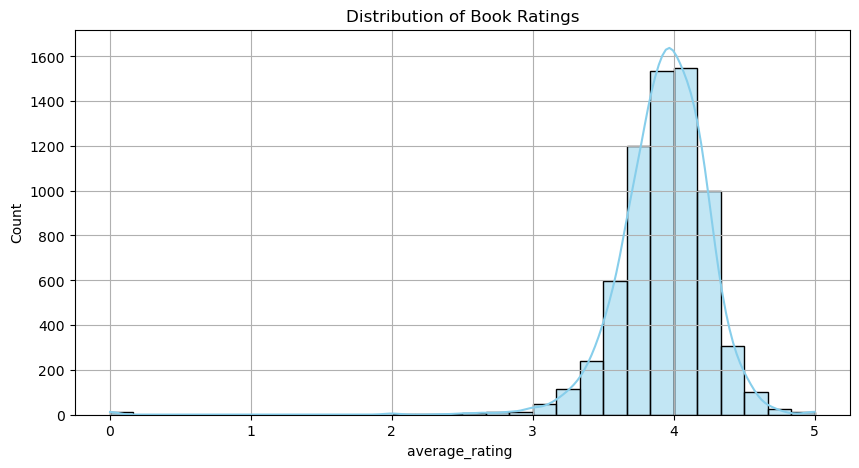

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(Data['average_rating'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Book Ratings')
plt.xlabel('average_rating ')
plt.ylabel('Count')
plt.grid(True)
plt.show()

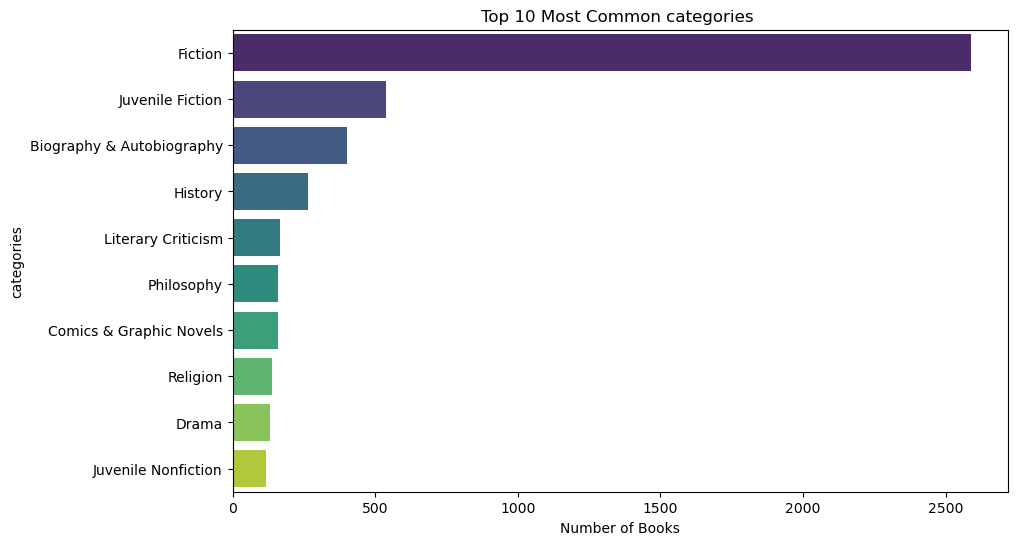

In [32]:
top_categories  = Data['categories'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_categories .values, y=top_categories .index, palette='viridis')
plt.title('Top 10 Most Common categories ')
plt.xlabel('Number of Books')
plt.ylabel('categories')
plt.show()

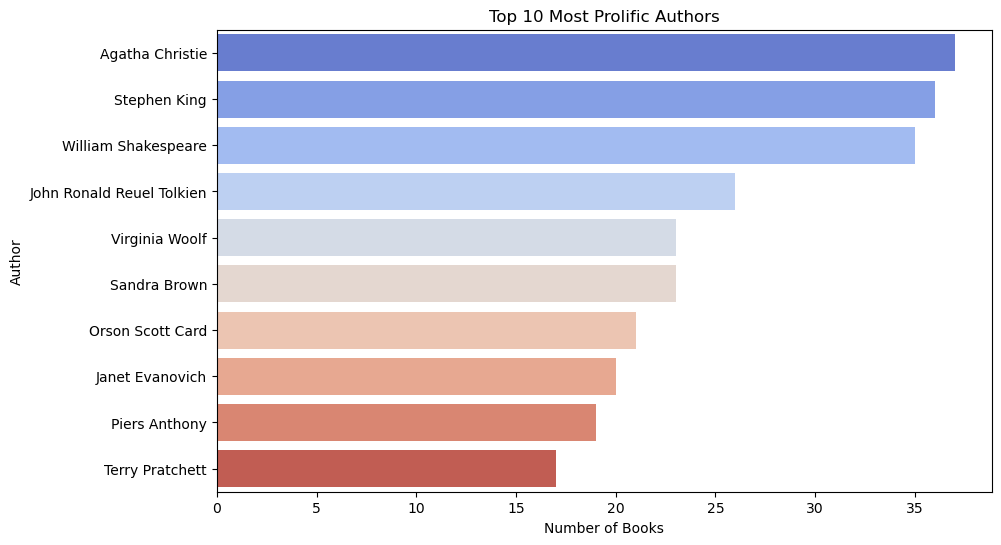

In [34]:
top_authors = df['authors'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='coolwarm')
plt.title('Top 10 Most Prolific Authors')
plt.xlabel('Number of Books')
plt.ylabel('Author')
plt.show()

In [36]:
published_year = Data['published_year'].value_counts()

In [38]:
publications = published_year.mean()
published_year = published_year[published_year>= publications]

In [40]:
colors = ['blue' if count >= 300 else 'red' for count in published_year]

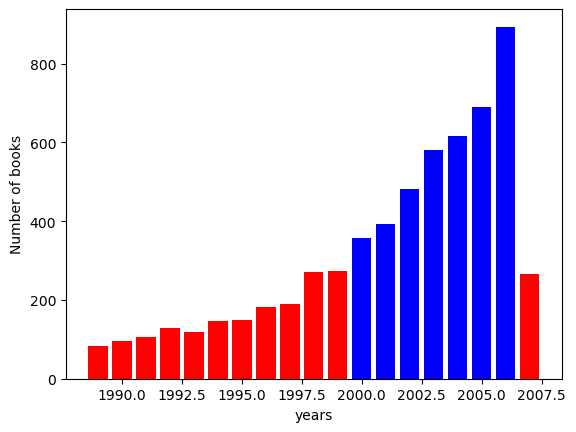

In [42]:
plt.bar(published_year.index, published_year.values, color=colors)
plt.ylabel("Number of books")
plt.xlabel("years")
plt.show()

In [44]:
Data['published_year'].unique()

array([2004., 2000., 1982., 1993., 2002., 1977., 1998., 1994., 1996.,
       1995., 2003., 2001., 1997., 2007., 2005., 2006., 1992., 1970.,
       1978., 1986., 1953., 1979., 1966., 1976., 1971., 1960., 1991.,
       1962., 1981., 1963., 1999., 1989., 1988., 1990., 1965., 2009.,
       2010., 1984., 1945., 1985., 1980., 1964., 1983., 1968., 1973.,
       1987., 1972., 1943., 1969., 1940., 1967., 2008., 1949., 1959.,
       1961., 1975., 1876., 1955., 1939., 1958., 1948.,   nan, 1927.,
       1952., 1974., 1942., 1946., 1950., 2017., 1957., 2012., 2019.,
       2011., 1956., 1938., 1941., 2015., 2014., 1947., 1954., 1925.,
       1914., 2013., 1929., 1934., 1951., 1901., 1944., 1930., 1904.,
       1936., 1926., 1928., 1853., 2018.])

In [46]:
Data['published_year']=Data['published_year'].astype(float)

In [48]:
for col in Data.columns:
    unique_count = Data[col].nunique()
    print(f"{col}: {unique_count} unique_count")

isbn13: 6810 unique_count
isbn10: 6810 unique_count
title: 6398 unique_count
subtitle: 2009 unique_count
authors: 3780 unique_count
categories: 567 unique_count
thumbnail: 6481 unique_count
description: 6474 unique_count
published_year: 94 unique_count
average_rating: 200 unique_count
num_pages: 915 unique_count
ratings_count: 3881 unique_count


In [50]:
Data["missing_description"] = np.where(Data['description'].isna(),1,0)
Data['book_age'] = 2025-Data['published_year']

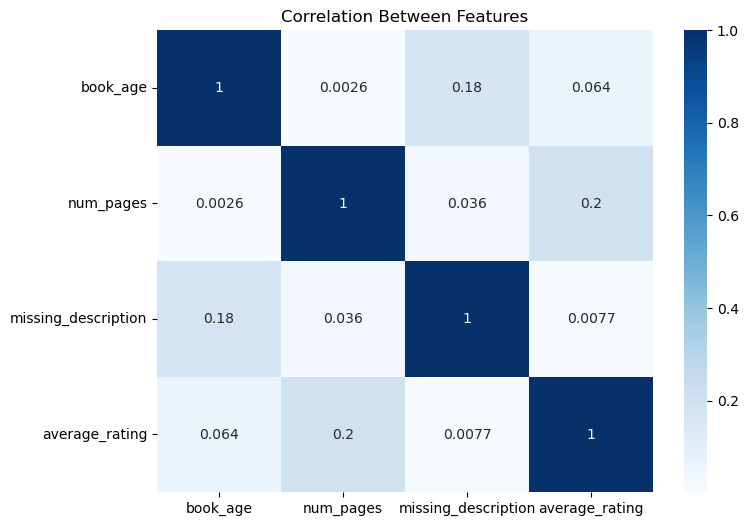

In [52]:
plt.figure(figsize=(8,6))
col_of_interest=sns.heatmap(Data[['book_age', 'num_pages', 'missing_description', 'average_rating']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Between Features')
plt.show()

In [54]:
top_high_rating_books = df.groupby(['title', 'average_rating'])['title'].count().to_frame()
top_high_rating_books.rename(columns={'title': 'total_book'}, inplace=True)
top_high_rating_books.sort_values("total_book", ascending=False, inplace=True)

In [56]:
top_10_books = top_high_rating_books.head(10)

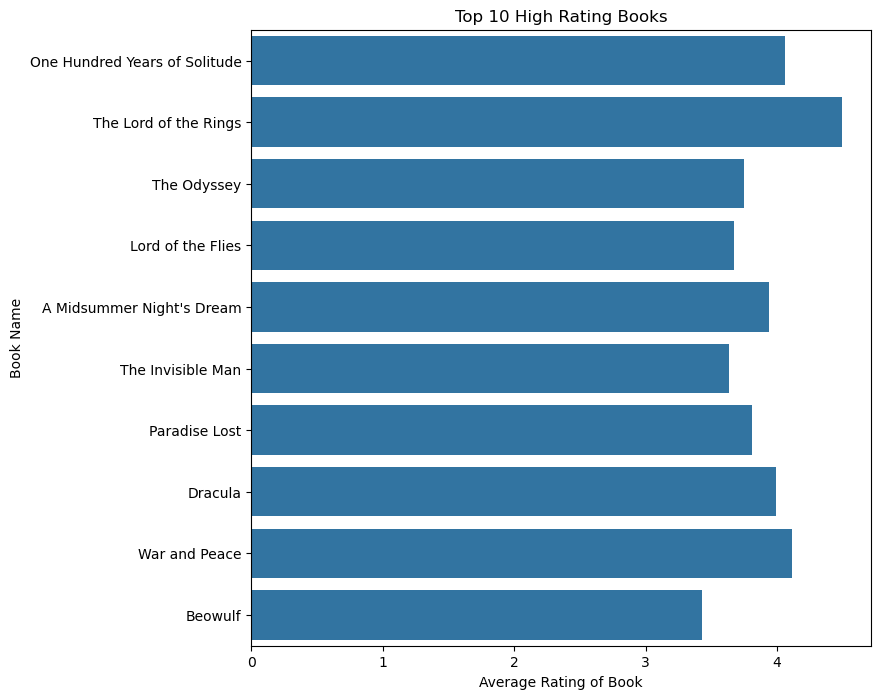

In [58]:
plt.figure(figsize=(8, 8))
sns.barplot(data=top_10_books.reset_index(), 
            x='average_rating', 
            y='title')
plt.ylabel("Book Name")
plt.xlabel("Average Rating of Book")
plt.title("Top 10 High Rating Books")


plt.show()

In [60]:
bins = [0, 3.5, 4.2, 5]
labels = ['low', 'medium', 'high']
Data['rating_class'] = pd.cut(Data['average_rating'], bins=bins, labels=labels)

In [62]:
model_data = Data.dropna(subset=['published_year', 'num_pages', 'categories']).copy()


In [64]:
model_data['main_category'] = model_data['categories'].apply(
    lambda x: x.split('/')[0].strip() if isinstance(x, str) else 'Unknown'
)

model_data['title_word_count'] = model_data['title'].apply(lambda x: len(str(x).split()))
model_data['desc_length'] = model_data['description'].apply(lambda x: len(str(x)))

In [66]:
top_categories = model_data['main_category'].value_counts().head(15).index
model_data['category_group'] = np.where(
    model_data['main_category'].isin(top_categories),
    model_data['main_category'],
    'Other'
)

In [68]:
top_authors = model_data['authors'].value_counts().head(30).index
model_data['author_group'] = np.where(
    model_data['authors'].isin(top_authors),
    model_data['authors'],
    'Other'
)

In [70]:
features = [    'num_pages', 'book_age', 'missing_description', 
    'category_group', 'author_group']
X = model_data[features].copy()
y = model_data['rating_class']

In [72]:
print("Missing values in target variable (y):", y.isnull().sum())


Missing values in target variable (y): 10


In [74]:
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]


print("Missing values after cleaning:", y.isnull().sum())

Missing values after cleaning: 0


In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)


In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['num_pages', 'book_age']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['category_group', 'author_group', 'missing_description'])
    ])

In [80]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced'
    ))
])

In [82]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['num_pages', 'book_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category_group',
                                                   'author_group',
                                                   'missing_description'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced'))])

In [83]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score,classification_report, confusion_matrix, ConfusionMatrixDisplay

In [84]:
y_pred = model.predict(X_test)

In [85]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')

In [86]:
print("\nClassification Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")



Classification Metrics:
Accuracy: 0.6854
Precision : 0.6670
Recall : 0.6854
F1-Score : 0.6750


In [87]:
model_data['rating_class'].value_counts()

rating_class
medium    5092
high      1101
low        465
Name: count, dtype: int64

In [88]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.33      0.25      0.28       220
         low       0.15      0.15      0.15        93
      medium       0.79      0.83      0.81      1019

    accuracy                           0.69      1332
   macro avg       0.42      0.41      0.41      1332
weighted avg       0.67      0.69      0.67      1332



In [111]:
popularity_data=Data[['title','authors', 'categories', 'average_rating', 'ratings_count']]
popularity_data = popularity_data.drop_duplicates(subset='title')
top_100_books = popularity_data.sort_values(by=['average_rating', 'ratings_count'], ascending=False).head(100)

In [113]:
top_100_books.head()

,title,authors,categories,average_rating,ratings_count
6671,The Diamond Color Meditation,John Diamond,Health & Fitness,5.0,5.0
4281,Middlesex Borough,NaN,History,5.0,2.0
1441,Fanning the Flame,Christopher J. H. Wright,Religion,5.0,1.0
3580,Colossians and Philemon,Robert McL Wilson,Religion,5.0,1.0
5398,The Complete Theory Fun Factory,Katie Elliott;Ian Martin,Juvenile Nonfiction,5.0,1.0


In [117]:
top_100_books.reset_index(drop=True, inplace=True)
top_100_books.columns = ['Title','Author', 'categories', 'Average_Rating', 'Ratings_count']

In [125]:
for index, row in top_100_books.iterrows():
    print(f'''
    Title: {row['Title']}
    Author: {row['Author']}
    Categories: {row['categories']}
    Average Rating: ⭐ {row['Average_Rating']} — Reviews: 📝 {row['Ratings_count']}
    ''')


    Title: The Diamond Color Meditation
    Author: John Diamond
    Categories: Health & Fitness
    Average Rating: ⭐ 5.0 — Reviews: 📝 5.0
    

    Title: Middlesex Borough
    Author: nan
    Categories: History
    Average Rating: ⭐ 5.0 — Reviews: 📝 2.0
    

    Title: Fanning the Flame
    Author: Christopher J. H. Wright
    Categories: Religion
    Average Rating: ⭐ 5.0 — Reviews: 📝 1.0
    

    Title: Colossians and Philemon
    Author: Robert McL Wilson
    Categories: Religion
    Average Rating: ⭐ 5.0 — Reviews: 📝 1.0
    

    Title: The Complete Theory Fun Factory
    Author: Katie Elliott;Ian Martin
    Categories: Juvenile Nonfiction
    Average Rating: ⭐ 5.0 — Reviews: 📝 1.0
    

    Title: Ecuador Nature Guide
    Author: Christopher D. Jiggins
    Categories: Botanique
    Average Rating: ⭐ 5.0 — Reviews: 📝 1.0
    

    Title: The Irish Anatomist
    Author: Keith Donohue
    Categories: Biography & Autobiography
    Average Rating: ⭐ 5.0 — Reviews: 📝 1.0
    

